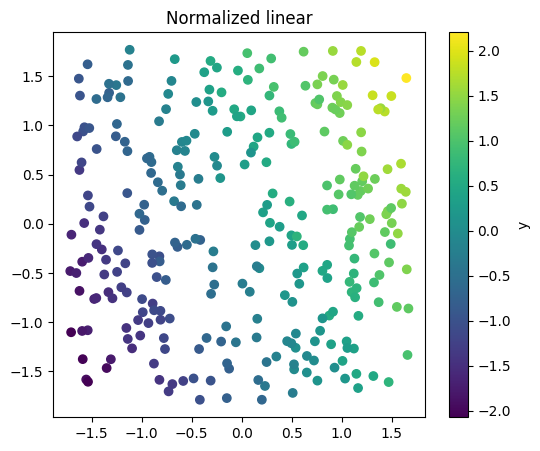

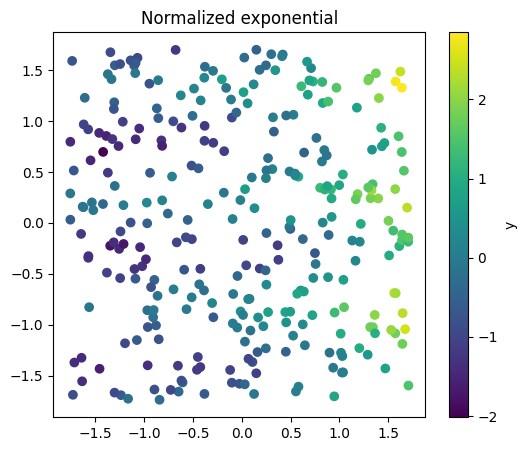

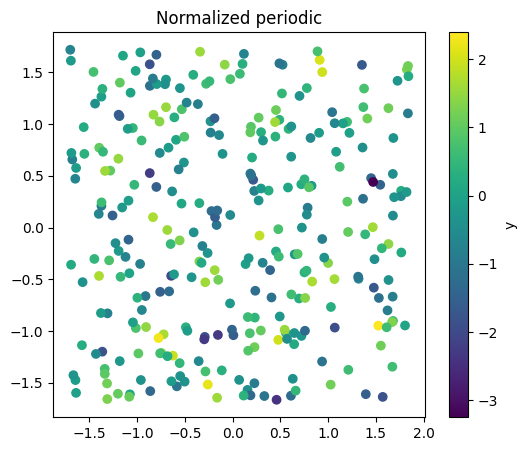

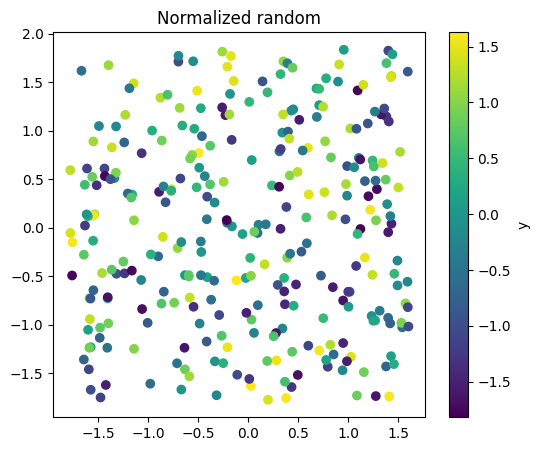

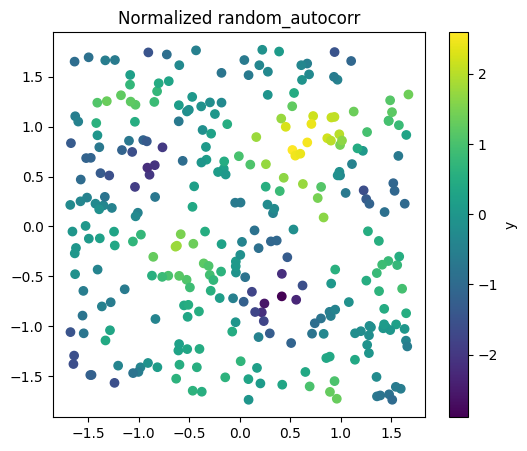


=== Comparison of CV methods ===

       Function       Random CV      Spatial CV Importance-weighted CV KMM-weighted spatial CV
         linear 0.0085 ± 0.0012 0.0084 ± 0.0012        0.0130 ± 0.0057         0.0093 ± 0.0015
    exponential 0.3517 ± 0.0764 0.4015 ± 0.1024        0.5830 ± 0.2770         0.4472 ± 0.1199
       periodic 1.0287 ± 0.0849 1.0120 ± 0.2031        1.6780 ± 0.7356         1.1101 ± 0.3056
         random 1.0039 ± 0.0522 0.9948 ± 0.0402        1.1643 ± 0.1650         1.0603 ± 0.0710
random_autocorr 0.9631 ± 0.0852 1.0907 ± 0.5135        1.4101 ± 0.7539         1.0991 ± 0.5372

Results saved to results.json


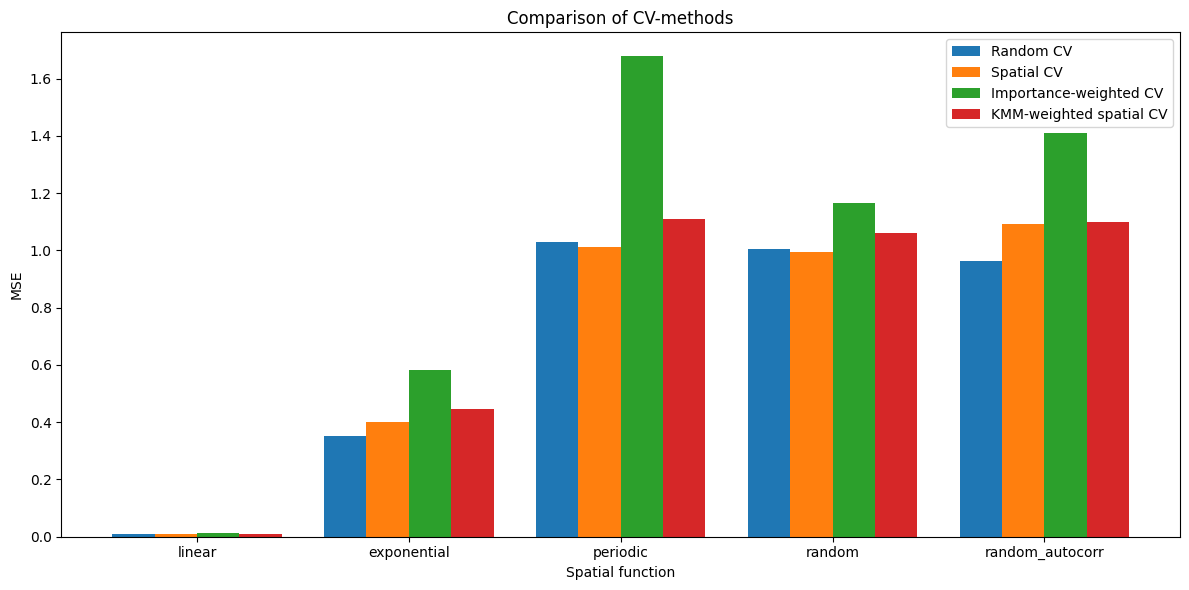

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from CV_Methods import run_comparison

results, df_results = run_comparison(n_folds=5, n_samples=300, noise_std=0.3, gamma=0.5, B=10)

print("\n=== Comparison of CV methods ===\n")
print(df_results.to_string(index=False))

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)
print("\nResults saved to results.json")

plt.figure(figsize=(12, 6))
funcs = df_results['Function'].values
methods = ['Random CV', 'Spatial CV', 'Importance-weighted CV', 'KMM-weighted spatial CV']
data = np.zeros((len(funcs), len(methods)))
for i, func in enumerate(funcs):
    for j, meth in enumerate(methods):
        val = float(df_results[df_results['Function'] == func][meth].values[0].split(' ± ')[0])
        data[i, j] = val

x = np.arange(len(funcs))
width = 0.2
for j, meth in enumerate(methods):
    plt.bar(x + j * width, data[:, j], width, label=meth)

plt.xlabel('Spatial function')
plt.ylabel('MSE')
plt.title('Comparison of CV-methods')
plt.xticks(x + width * 1.5, funcs)
plt.legend()
plt.tight_layout()
plt.show()